In [1]:
using ITensors, ITensorMPS

In [2]:
using CairoMakie
using Makie.Colors
using JLD2

## MPS

In [4]:
include("mps_funcs.jl")

entanglement_entropy_svd

In [5]:
L = 8
chi = 1024
cutoff = 1E-8
N = L^2

64

In [ ]:
ket_es = mps_equal_superposition(N)
sites = siteinds(ket_es);

In [ ]:
thetas = collect(-20:1:20)/500 .+ pi/4;

In [17]:
zzs = ITensor[]
for y in 2:L
    i0, i1 = coor2idx((1,y), L), coor2idx((y,1), L)
    println(i0, " ", i1)
    push!(zzs, op("Z", sites[i0]) * op("Z", sites[i1]))
end

for x in 2:L-1
    i0, i1 = coor2idx((x,L), L), coor2idx((L,x), L)
    println(i0, " ", i1)
    push!(zzs, op("Z", sites[i0]) * op("Z", sites[i1]))
end

2 16
3 17
4 32
5 33
6 48
7 49
8 64
9 63
24 62
25 61
40 60
41 59
56 58


In [18]:
checklinkdim = true
zz_theta = []
for theta in thetas
  println("$(theta/pi)")
  gates = make_sqr_whip_gates_obc(L, theta)
  zytensors = make_tensormap_of_ZY(gates, sites)
  psi = deepcopy(ket_es)
  make_contraction!(gates, zytensors, psi, chi, cutoff, checklinkdim)
  normalize!(psi)
  
  if (L <= 4) & (abs(theta-pi/4)<1e-16)
    s_conf = check_ground_state_configuration(psi)
    println(s_conf)
  end

  tmp = []
  for zz in zzs
    zz_val = inner(psi, apply([zz], psi))
    push!(tmp, zz_val)
  end
  push!(zz_theta, tmp)
end
zz_theta = stack(zz_theta);

0.23726760455264836
link dimensions: 189
0.23790422432501596
link dimensions: 189
0.23854084409738352
link dimensions: 187
0.2391774638697511
link dimensions: 184
0.2398140836421187
link dimensions: 181
0.24045070341448627
link dimensions: 180
0.24108732318685386
link dimensions: 176
0.24172394295922142
link dimensions: 171
0.242360562731589
link dimensions: 166
0.2429971825039566
link dimensions: 160
0.24363380227632417
link dimensions: 151
0.24427042204869176
link dimensions: 141
0.24490704182105935
link dimensions: 127
0.24554366159342692
link dimensions: 110
0.2461802813657945
link dimensions: 91
0.2468169011381621
link dimensions: 71
0.24745352091052966
link dimensions: 60
0.24809014068289725
link dimensions: 58
0.24872676045526484
link dimensions: 58
0.2493633802276324
link dimensions: 58
0.25
link dimensions: 2
0.25063661977236756
link dimensions: 58
0.2512732395447352
link dimensions: 58
0.25190985931710275
link dimensions: 58
0.2525464790894703
link dimensions: 60
0.2531830988

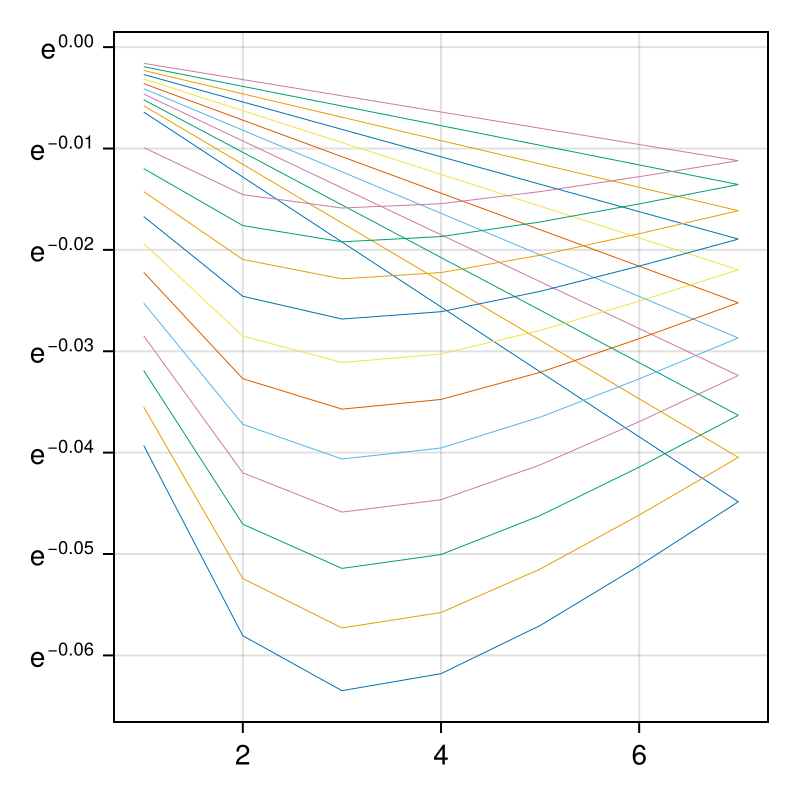

In [30]:
f = Figure(size=(400,400))

ax = Axis(f[1,1], yscale=log)

for i in eachindex(thetas[15:25])
    lines!([collect(1:L-1);collect(L-2:-1:1)], zz_theta[:,i], linewidth=0.5)
end

current_figure()

In [40]:
x = abs.(thetas .- pi/4).^2
y1 = (log.(zz_theta[1,:]) - log.(zz_theta[2,:]))/1;
y2 = (log.(zz_theta[end,:]) - log.(zz_theta[end-1,:]))/1;

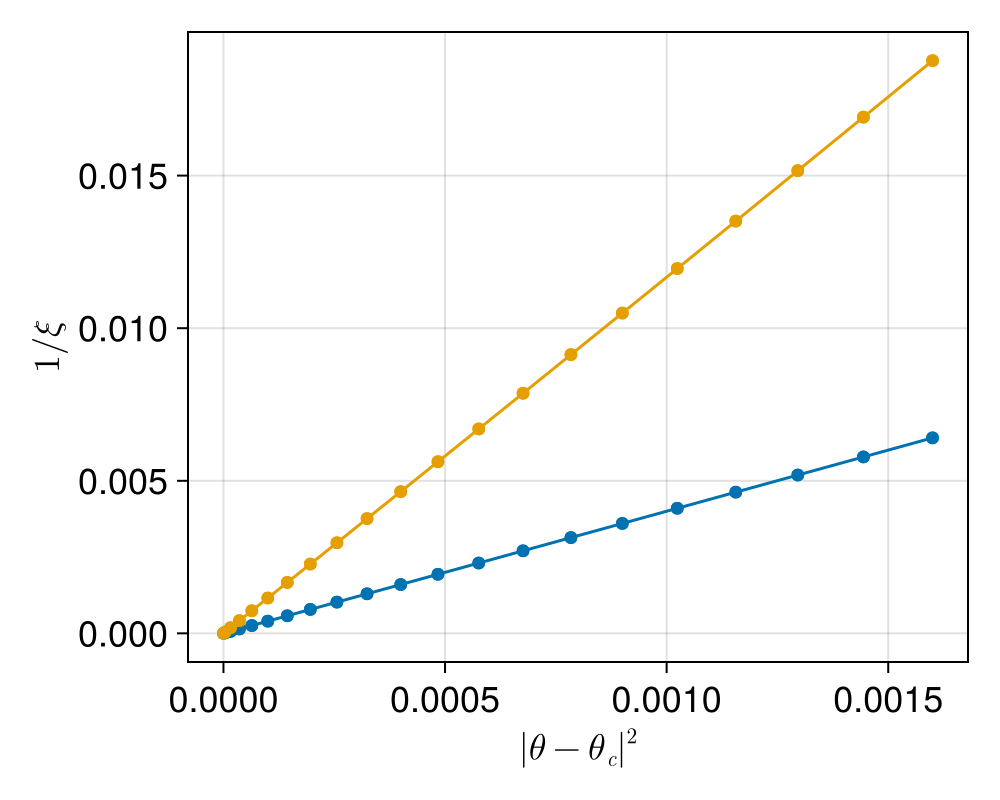

In [41]:
f = Figure(size=(500,400),fontsize=18)
ax = Axis(f[1,1], xlabel=L"|\theta-\theta_c|^2", ylabel=L"1/\xi")

scatterlines!(x, y1)
scatterlines!(x, y2)

# save("./zz_cor.png",f)
current_figure()

## PEPS

In [4]:
include("peps_funcs.jl")

get_maxlinkdim (generic function with 1 method)

In [5]:
L = 30
ket_es = twodim_sqr_peps(L, "+"^(L*L));
sites = get_siteinds(ket_es);

In [7]:
# thetas = pi*collect(-5:1:5)/1000 .+ pi/4;
thetas = pi*collect(0:1:6)/100 .+ pi/4;
println(thetas .- pi/4)
zzs_loc = Tuple[]
for y in L-1:-1:1
    i0, i1 = coor2idx((L,y), L), coor2idx((y,L), L)
    println(i0, " ", i1)
    # push!(zzs, op("Z", sites[i0]) * op("Z", sites[i1]))
    push!(zzs_loc, (i0,i1))
end
# for x in 2:L-1
#     i0, i1 = coor2idx((x,L), L), coor2idx((L,x), L)
#     println(i0, " ", i1)
#     # push!(zzs, op("Z", sites[i0]) * op("Z", sites[i1]))
#     push!(zzs_loc, (i0,i1))
# end
println(length(zzs_loc))

[0.0, 0.031415926535897976, 0.06283185307179584, 0.09424777960769382, 0.12566370614359168, 0.15707963267948966, 0.18849555921538763]
899 870
898 840
897 810
896 780
895 750
894 720
893 690
892 660
891 630
890 600
889 570
888 540
887 510
886 480
885 450
884 420
883 390
882 360
881 330
880 300
879 270
878 240
877 210
876 180
875 150
874 120
873 90
872 60
871 30
29


In [8]:
# println(thetas./pi .- 0.25)

In [9]:
chi = 32
global min_chi = 4
cutoff = 1E-8
min_chi

4

In [10]:
zz_theta = []
for theta in thetas
  println("$(theta-pi/4)")
  psi = deepcopy(ket_es)
  gates = make_sqr_whip_gates_obc(L, theta)
  zytensors = make_tensormap_of_ZY(gates, sites)
  make_contraction_peps!(gates, zytensors, psi, chi, cutoff)
  # contract to obtain the normalization factor
  # val3 = contract_twopeps_naive(psi, psi, chi, cutoff, plev=0)
  val3 = contract_twopeps_bdr_mps(psi, psi, chi, cutoff, plev=0)
  # observable
  tmp = []
  for loc in zzs_loc
    i0,i1 = loc
    zzpsi = deepcopy(psi)
    zzpsi[i0] *= op("Z", sites[i0])
    noprime!(zzpsi[i0], tags="Site")
    zzpsi[i1] *= op("Z", sites[i1])
    noprime!(zzpsi[i1], tags="Site")
    # szsz_val = contract_twopeps_naive(zzpsi, psi, chi, cutoff, plev=0)
    zz_val, coeff, link_dims = contract_twopeps_bdr_mps(zzpsi, psi, chi, cutoff, plev=1)
    push!(tmp, real(zz_val/val3))
  end
  push!(zz_theta, tmp)
end
zz_theta = stack(zz_theta);

0.0
0.031415926535897976
0.06283185307179584
0.09424777960769382
0.12566370614359168
0.15707963267948966
0.18849555921538763


In [ ]:
# [i<5 ? 1 : 0 for i=1:10]
zz_theta_0 = abs.(zz_theta);

In [33]:
@. zz_theta_ideal_funcs(d,phi) = (sin(2phi)/(1+abs(cos(2phi))))^(2d)

zz_theta_ideal_funcs (generic function with 1 method)

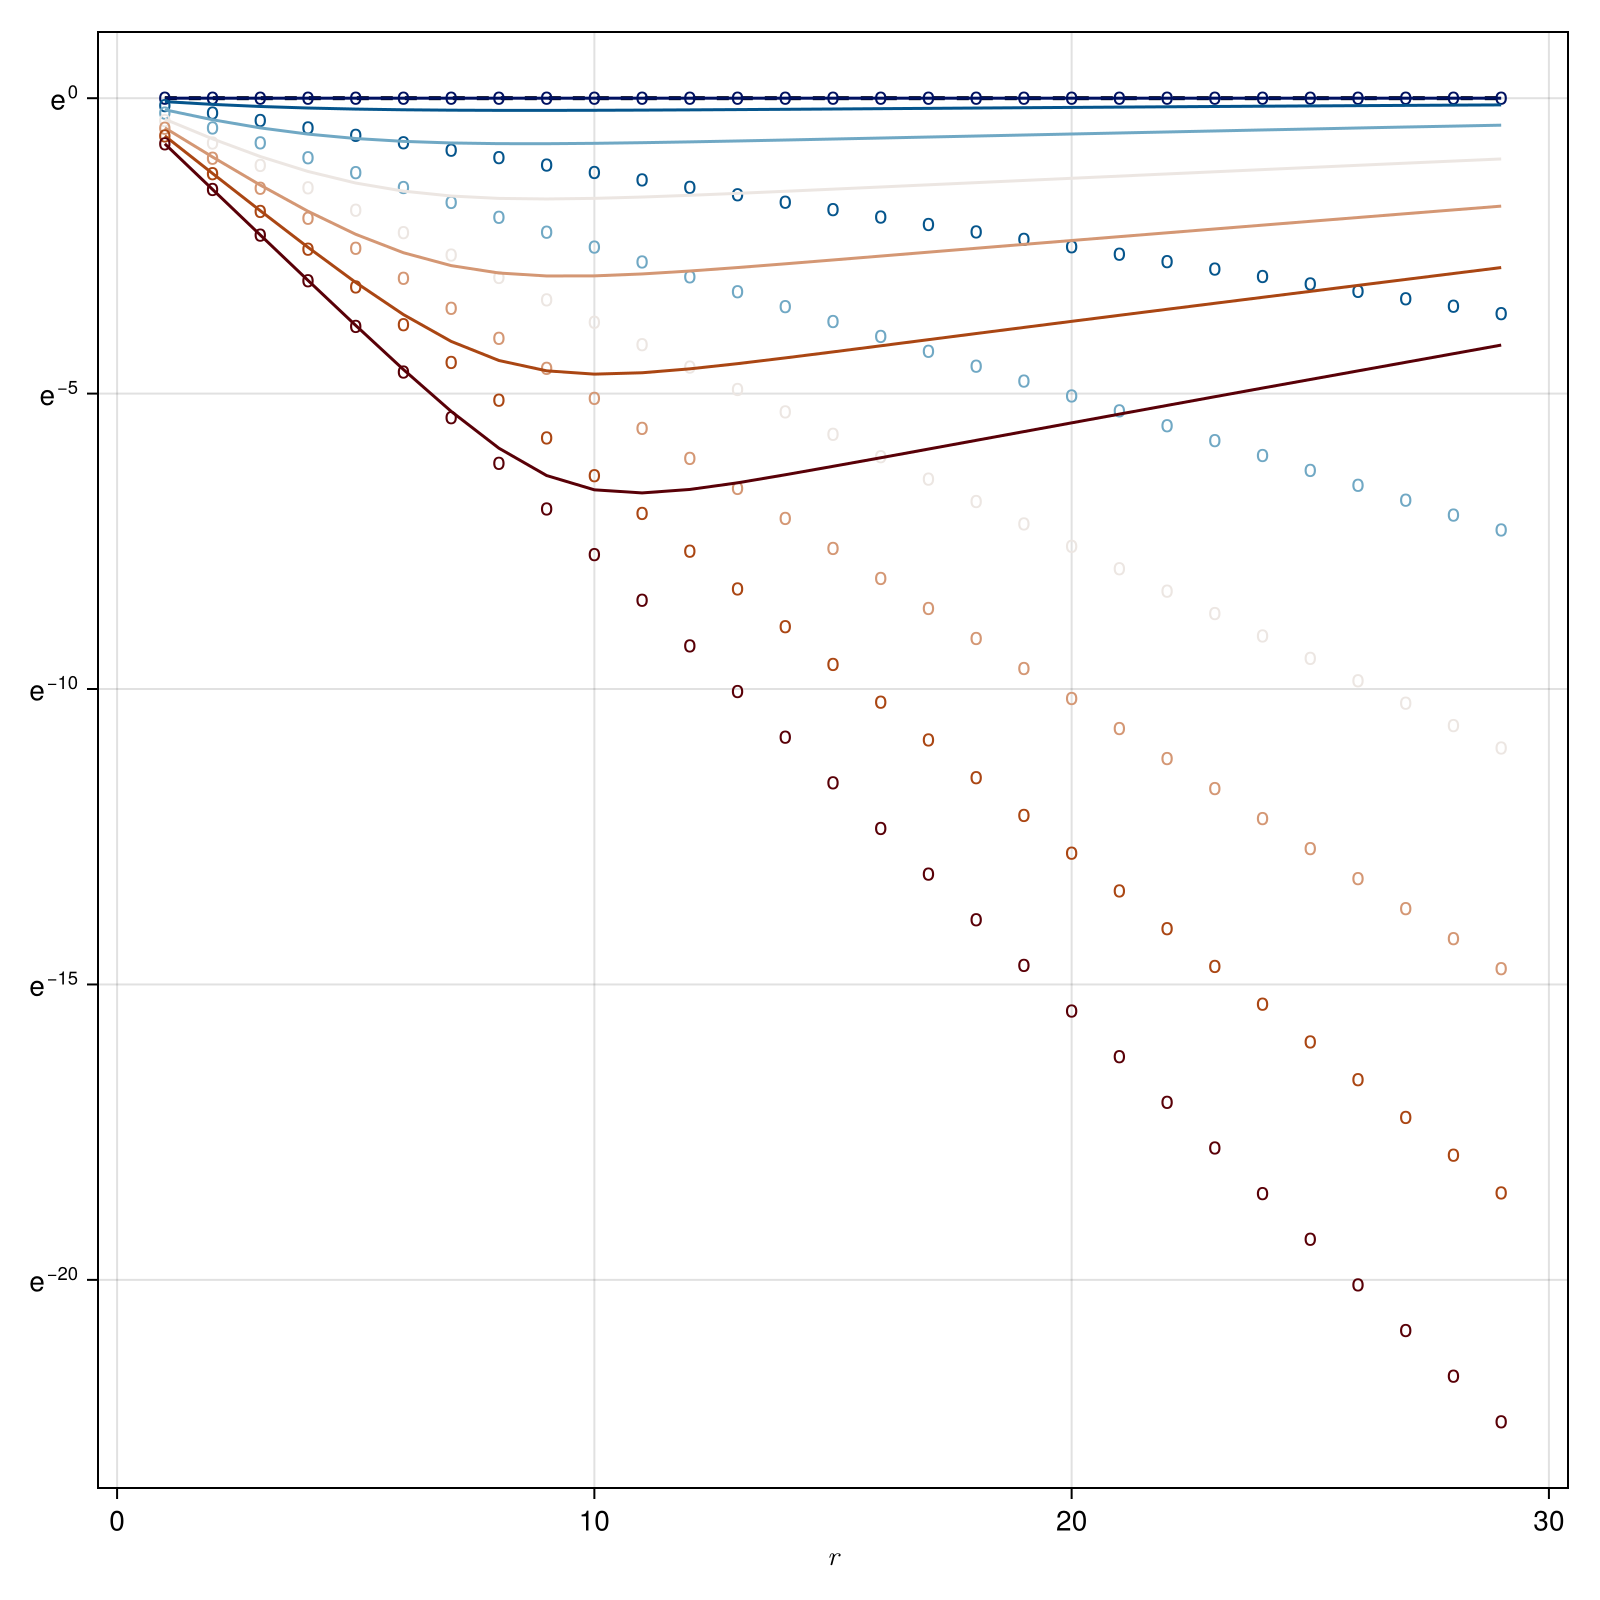

In [15]:
f = Figure(size=(800,800))

ax = Axis(f[1,1], yscale=log, xlabel=L"r")

rs = collect(1:L-1)
cs = :black
if length(rs) < length(zz_theta_0[:,1])
    rs = [collect(1:L-1);collect(L-2:-1:1)]
    cs = [i<L-1 ? :black : :blue for i=1:2L-3]
end

mycl = cgrad(:vik, length(thetas), categorical = true)

lines!(rs, color=cs, zz_theta_0[:,1], linewidth=2.0, linestyle=:dash)
for i in eachindex(thetas)
    lines!(rs, zz_theta_0[:,i], color=mycl[i])
    scatter!(rs, zz_theta_ideal_funcs(rs, thetas[i]), color=mycl[i], marker='o', markersize=12)
end

f

In [17]:
x = abs.(thetas .- pi/4)
y3 = (log.(zz_theta_0[1,:]) - log.(zz_theta_0[5-1,:]))/(5-1);
y4 = (log.(zz_theta_ideal_funcs(rs[1], thetas)) - log.(zz_theta_ideal_funcs(rs[L-1], thetas)))/(L-1);

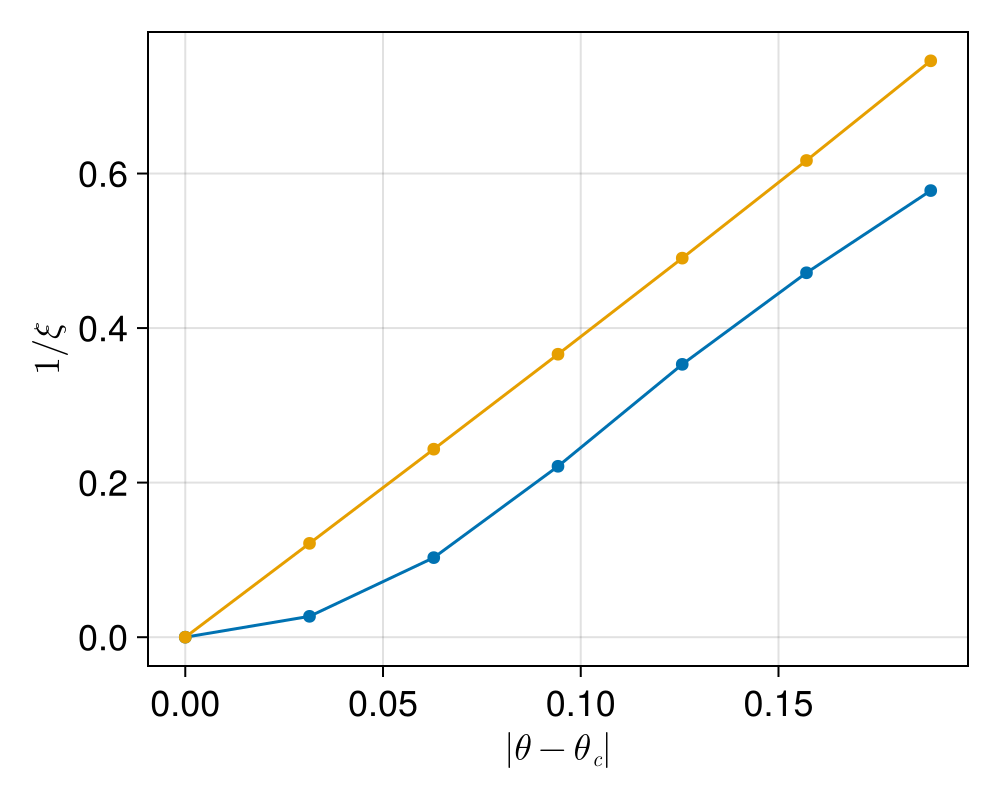

In [18]:
f = Figure(size=(500,400),fontsize=18)
ax = Axis(f[1,1], xlabel=L"|\theta-\theta_c|", ylabel=L"1/\xi")

scatterlines!(x, y3)
scatterlines!(x, y4)

# save("./zz_cor.png",f)
current_figure()

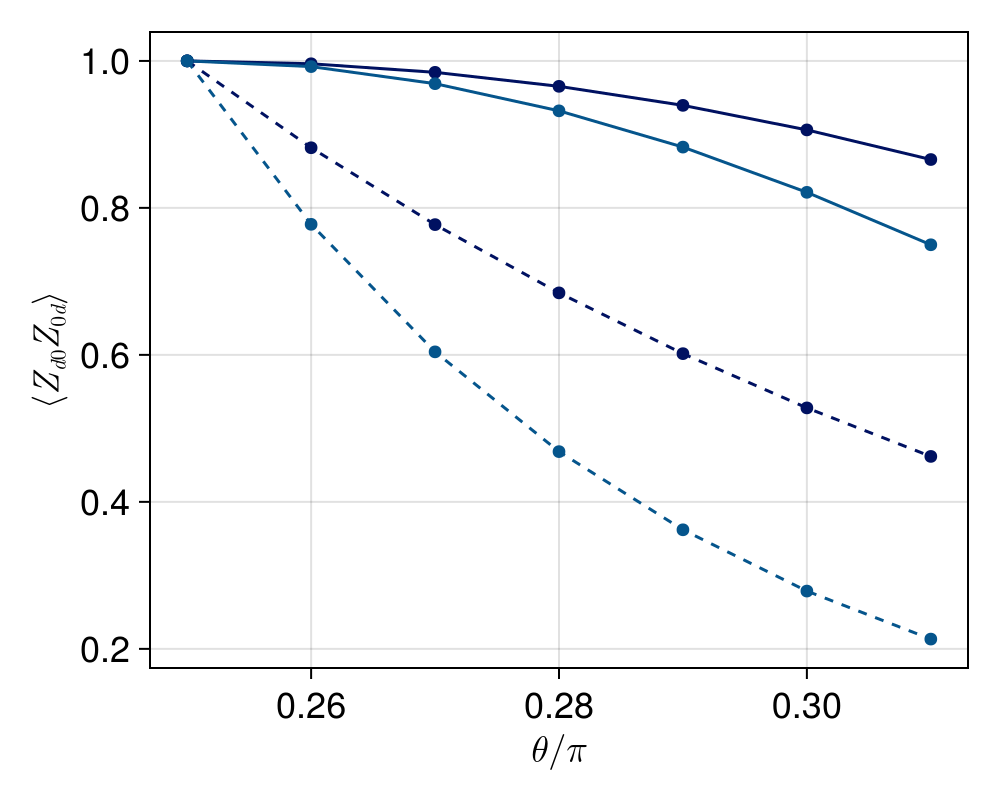

In [113]:
f = Figure(size=(500,400),fontsize=18)
ax = Axis(f[1,1], xlabel=L"\theta/\pi", ylabel=L"\langle Z_{d0}Z_{0d}\rangle")

scatterlines!(thetas./pi, zz_theta_0[1,:], color=mycl[1])
scatterlines!(thetas./pi, zz_theta_0[2,:], color=mycl[2])
scatterlines!(thetas./pi, zz_theta_ideal_funcs(rs[1], thetas), color=mycl[1], linestyle=:dash)
scatterlines!(thetas./pi, zz_theta_ideal_funcs(rs[2], thetas), color=mycl[2], linestyle=:dash)

# save("./zz_cor.png",f)
current_figure()

# FFS

In [1]:
using CairoMakie
using Makie.Colors
using JLD2

In [9]:
@. zz_theta_ideal_funcs(d,phi) = (sin(2phi)/(1+abs(cos(2phi))))^(2d)
file_str(L,chi,cutoff) = "2D_sqr_PEPS_Whip_MPO_L$(L)_Chi$(chi)_ZZ_$(cutoff)"

file_str (generic function with 1 method)

In [3]:
Ls = [10,20,30,40,50,60,80,100]
chi = 32

32

In [4]:
# X_s = []
Zd0Z0d_s = []
ZddZ00_s = []
Thetas = []
for L in Ls
    if L < 80
        cutoff = 1E-16
    else
        cutoff = 1E-8
    end
    data = load("data/scaling/$(file_str(L,chi,cutoff))_fss.jld2")
    println(keys(data))
    # push!(X_s, [sum(x)/(4*(L-1)) for x in data["saved_x0"]])
    zzs = stack(data["saved_zdz0"], dims=1)
    push!(Zd0Z0d_s, zzs[:,2:2:end])
    push!(ZddZ00_s, zzs[:,1:2:end])
    push!(Thetas, stack(data["saved_thetas"], dims=1))
end

["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]


In [84]:
# fig = Figure(size=(300*length(Ls),300), fontsize=20)

slope_d00d = [] #
for j in eachindex(Ls)
    # ax = Axis(fig[1,j], yscale=log10, xlabel=L"r")
    rs = collect(1:Ls[j]-1)
    mycl = cgrad(:vik, length(Thetas[j]), categorical = true)
    tmp = []
    for i in eachindex(Thetas[j])
        theta = Thetas[j][i]
        # scatter!(rs, zz_theta_ideal_funcs(rs, Thetas[j][i]), color=mycl[i], marker='o', markersize=12)
        # lines!(rs, Zd0Z0d_s[j][i,:], color=mycl[i])
        push!(tmp, (log(Zd0Z0d_s[j][i,1]) - log(Zd0Z0d_s[j][i,3]))/2)
    end
    push!(slope_d00d, tmp)
end

# save("figure/zd0z0d_decay.png", fig)

# fig

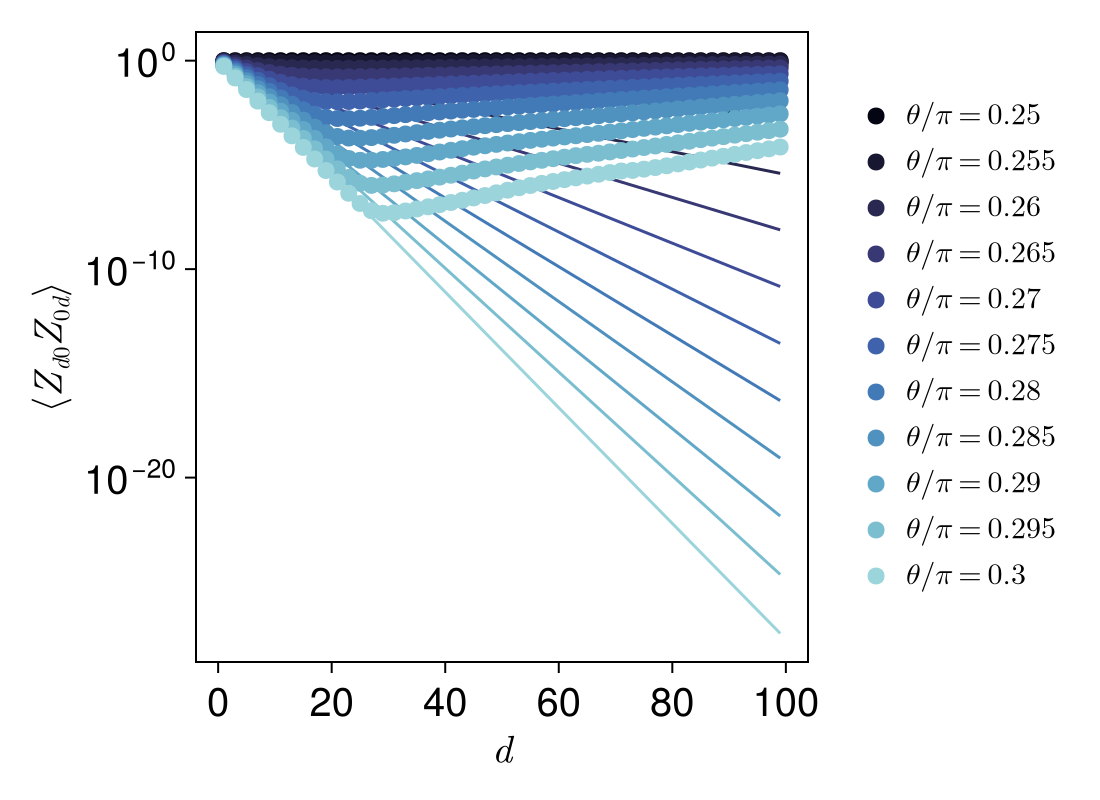

In [86]:
fig = Figure(size=(550,400), fontsize=20)
ax = Axis(fig[1,1], yscale=log10, xlabel=L"d", ylabel=L"\langle Z_{d0}Z_{0d}\rangle", xticks=0:20:100, xgridvisible=false, ygridvisible=false)
mycl = cgrad(:ice, length(Thetas[end])+2, categorical = true)
rs = collect(1:Ls[end]-1)
for i in eachindex(Thetas[end])
    lines!(rs, zz_theta_ideal_funcs(rs, Thetas[end][i]), color=mycl[i])
    scatter!(rs[1:2:end], Zd0Z0d_s[end][i,1:2:end], color=mycl[i], markersize=12, label=L"\theta/\pi=%$(round(Thetas[end][i]/pi,digits=3))")
end

Legend(fig[1,2], ax, labelsize=15, framevisible=false)

save("figure/zd0z0d_decay.svg", fig)

fig

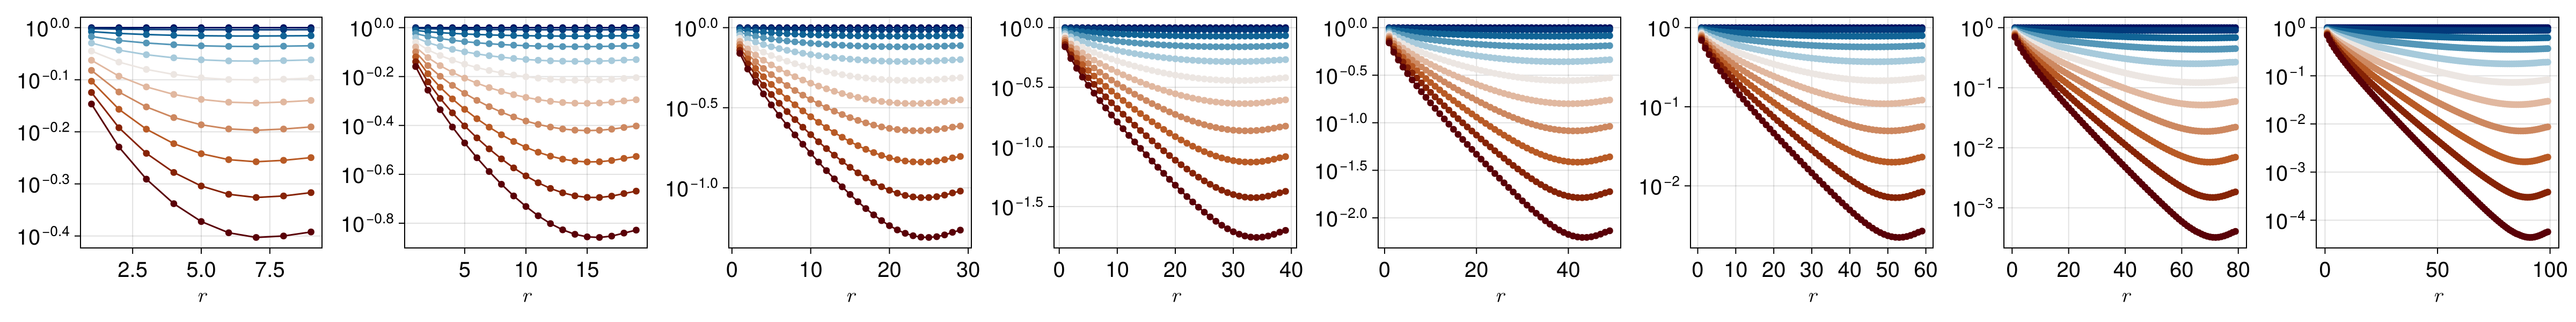

In [7]:
fig = Figure(size=(300*length(Ls),300), fontsize=20)

slope_dd00 = [] #
for j in eachindex(Ls)
    ax = Axis(fig[1,j], yscale=log10, xlabel=L"r")
    rs = collect(1:Ls[j]-1)
    mycl = cgrad(:vik, length(Thetas[j]), categorical = true)
    tmp = []
    for i in eachindex(Thetas[j])
        theta = Thetas[j][i]
        scatterlines!(rs, ZddZ00_s[j][i,:], color=mycl[i])
        push!(tmp, (log(ZddZ00_s[j][i,1]) - log(ZddZ00_s[j][i,3]))/2)
    end
    push!(slope_dd00, tmp)
end

save("figure/zddz00_decay.png", fig)

fig

8


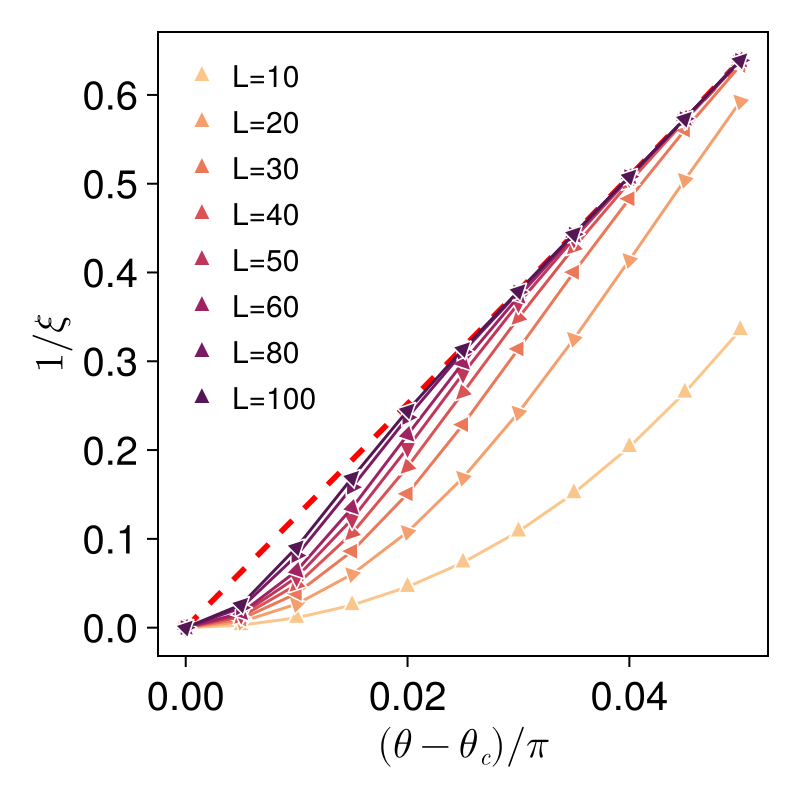

In [97]:
fig = Figure(size=(400,400), fontsize=20)
ax = Axis(fig[1,1], xlabel=L"(\theta-\theta_c)/\pi", ylabel=L"1/ξ", xgridvisible=false, ygridvisible=false)

mycl = cgrad(:matter, length(Ls)+2, categorical = true)[2:end]
y4 = (log.(zz_theta_ideal_funcs(1, Thetas[1])) - log.(zz_theta_ideal_funcs(3, Thetas[1])))/2;
lines!(Thetas[1]./pi .- 1/4, y4, color=:red, linestyle=:dash, linewidth=2.8)
for j in eachindex(Ls)
    lines!(Thetas[j]./pi .- 1/4, slope_d00d[j], color=mycl[j])
    scatter!(Thetas[j]./pi .- 1/4, slope_d00d[j], color=mycl[j], label="L=$(Ls[j])", 
    strokecolor=:white,strokewidth=0.8,
    marker=:utriangle, markersize=12; rotation = deg2rad(360*(j-1)/length(Ls)))
    # scatterlines!(Thetas[j].-pi/4, slope_dd00[j], color=mycl[j], linestyle=:dash)
end
println(length(Ls))
axislegend(ax, position=:lt, labelsize=15, framevisible=false)

save("figure/output_xi.svg", fig)

fig

In [10]:
file_str(L,chi,cutoff) = "2D_sqr_PEPS_Whip_MPO_L$(L)_Chi$(chi)_ZZ_$(cutoff)"
# Ls = [4,5,8,10,15,20,25,30,40]
Ls = [4,8,10,20,30,40,50,100]
# Ls = [10,20]
cutoff = 1E-8
chi = 32

32

In [11]:
X_s = []
XL1_s = [] # L,1 point
XLLm1_s = [] # L,L-1 point
ZZ_s = []
ThetaXs = []
for L in Ls
    data = load("data/scaling/$(file_str(L,chi,cutoff))_half_spp.jld2")
    println(keys(data))
    push!(X_s, [sum(x[2:end-1])/(2*L-4) for x in data["saved_x0"]])
    push!(XL1_s, [x[1] for x in data["saved_x0"]])
    push!(XLLm1_s, [x[L-1] for x in data["saved_x0"]])
    push!(ThetaXs, stack(data["saved_thetas"], dims=1))
    push!(ZZ_s, [x[1] for x in data["saved_zdz0"]])
end

["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]
["saved_x0", "total_time_sec", "saved_zdz0", "saved_linkdim", "saved_thetas"]


## Total X

In [46]:
@. totalX_ideal(theta) = (cos(2theta) + abs(cos(2theta)))/(2cos(theta))

totalX_ideal (generic function with 2 methods)

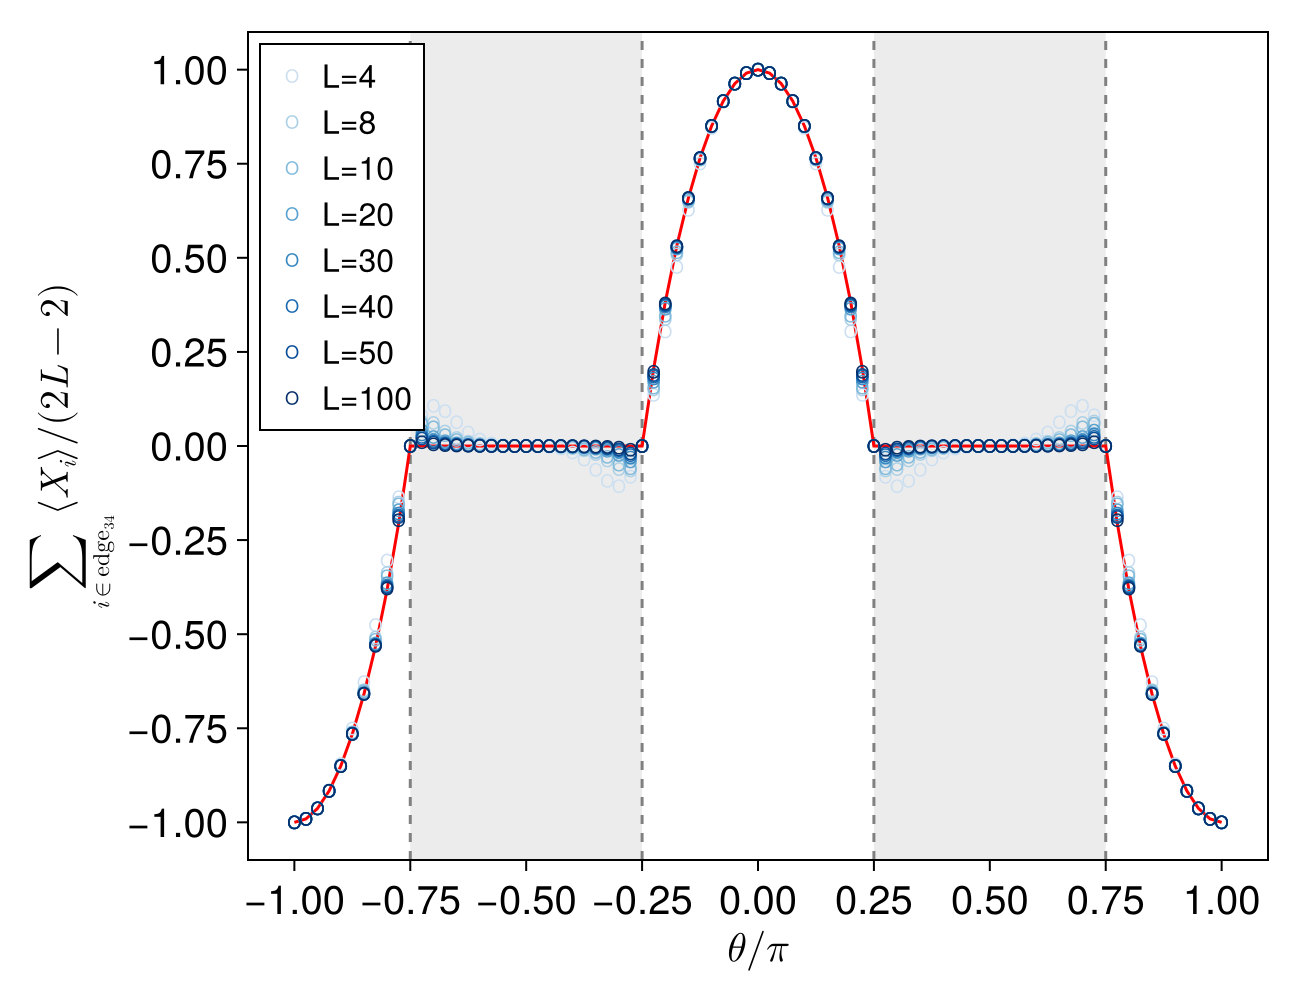

In [47]:
fig = Figure(size=(650,500), fontsize=20)
ax = Axis(fig[1,1], xlabel=L"\theta/\pi", ylabel=L"\sum_{i\in\mathrm{edge_{34}}}⟨X_i⟩/(2L-2)",
        yticks=-1.0:0.25:1.0, xticks=-1.0:0.25:1.0, xgridvisible=false, ygridvisible=false)

# 你要涂黑的区间
bands = [(-3/4, -1/4), (1/4, 3/4)]
# 画灰色（或黑色）填充带
for (x1, x2) in bands
    vspan!(ax, x1, x2; color = (:gray, 0.15))  # 0.15 是透明度，可改大更黑
    vlines!(ax, [x1, x2]; color = :gray, linestyle = :dash, linewidth = 1.5)
end
# lines!([-0.75,-0.25],[0.0,0.0], color=:red)
# lines!([0.75,0.25],[0.0,0.0], color=:red)
lines!(ThetaXs[end]./pi, totalX_ideal(ThetaXs[end]), color=:red)
mycl = cgrad(:Blues, length(Ls)+2, categorical = true)[3:end]
for j in eachindex(Ls)
    scatter!(ThetaXs[j]./pi, X_s[j], color=mycl[j], marker='O', label="L=$(Ls[j])")
end

axislegend(ax, position=:lt, framevisible=true, labelsize=16)
fig

In [37]:
using LsqFit
@. model(x, p) = p[1]*(x - x[1])^p[2]

x = ThetaXs[1]./pi
y = X_s[end]
println(x[31], x[32])
xw = x[31:40]
yw = y[31:40]
println(xw)

p0 = [1.0,1/8]
fit = curve_fit(model, xw, yw, p0)


-0.25-0.225
[-0.25, -0.225, -0.2, -0.175, -0.15, -0.125, -0.1, -0.075, -0.05, -0.025]


LsqFit.LsqFitResult{Vector{Float64}, Vector{Float64}, Matrix{Float64}, Vector{Float64}, Vector{LsqFit.LMState{LsqFit.LevenbergMarquardt}}}([2.701681572019797, 0.6333063631583108], [2.8017496468901777e-14, 0.06412264471460699, 0.026434824225461506, -0.007178249522932445, -0.03049706790200668, -0.04114267820112516, -0.03799625641141913, -0.020420860071820868, 0.012021591113165142, 0.05968818848606816], [0.0 0.0; 0.09669526619681615 -0.9636822002049705; … ; 0.360859255348324 -1.569084154229333; 0.3888060969394354 -1.5668794307843243], true, Iter     Function value   Gradient norm 
------   --------------   --------------
, Float64[])

In [34]:
using JSON

jdata = Dict(
    "Thetas"=>ThetaXs[1],
    "Ls"=>Ls,
    "sum_of_X"=>[X_s[j] for j in eachindex(Ls)]
    )

# 2. Load the data from the JLD2 file
# ------------------------------------
dirstr = "./data/scaling"
filestr = "2D_sqr_PEPS_Whip_MPO_Ls_Chi$(chi)_X_wo_corner_$(cutoff)"
# 3. Convert the data to JSON format and save to a .json file
# ------------------------------------------------------------
# The loaded_data is a dictionary, which is generally compatible with JSON types.
open("$dirstr/$filestr.json", "w") do io
    JSON.print(io, jdata, 4)
end

println("Data successfully saved to output.json")

Data successfully saved to output.json


## Single X

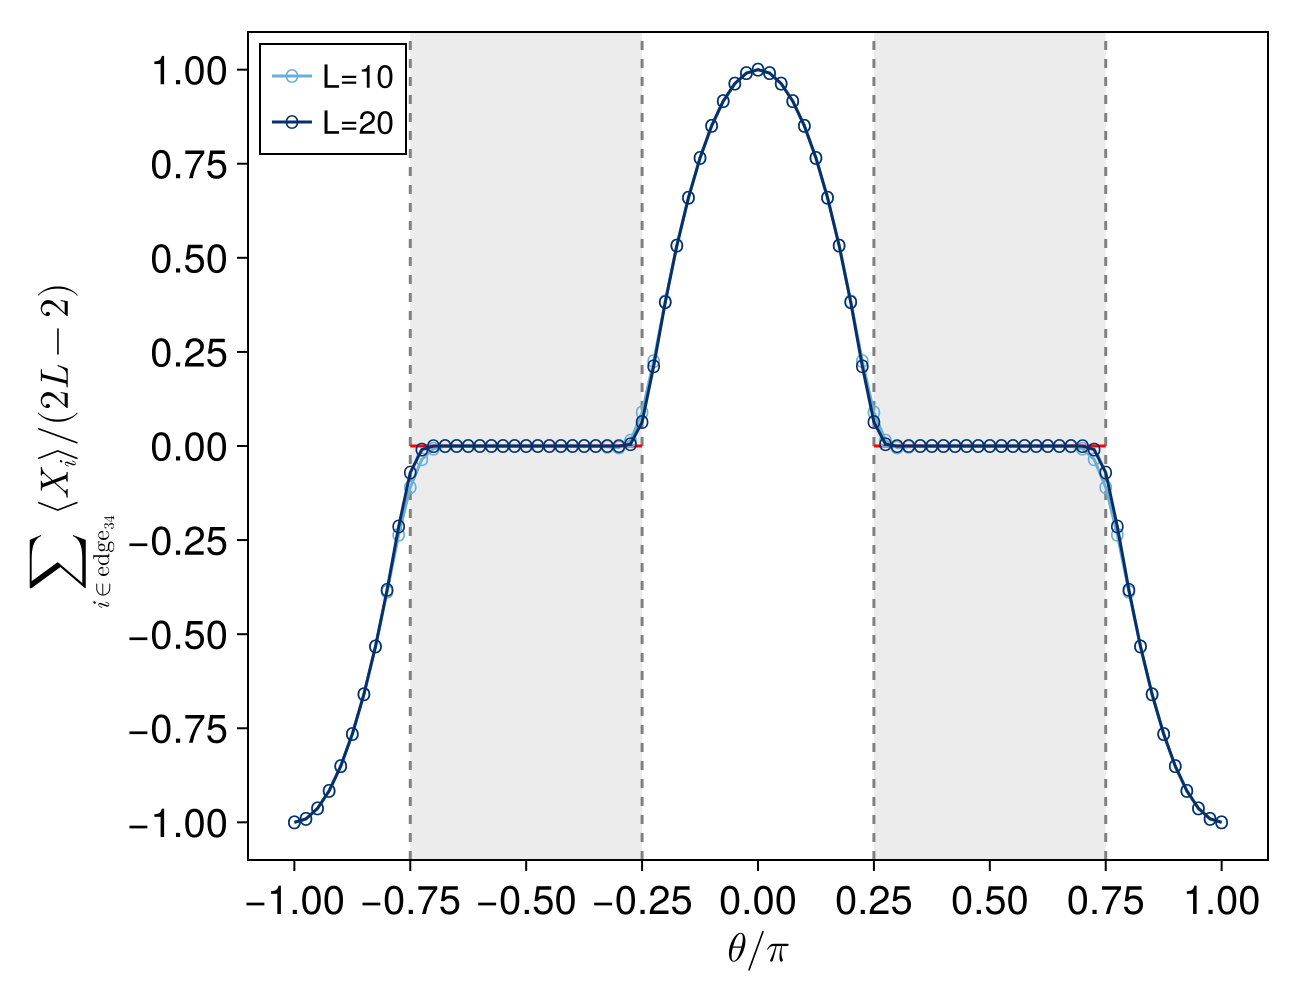

In [29]:
fig = Figure(size=(650,500), fontsize=20)
ax = Axis(fig[1,1], xlabel=L"\theta/\pi", ylabel=L"\sum_{i\in\mathrm{edge_{34}}}⟨X_i⟩/(2L-2)",
        yticks=-1.0:0.25:1.0, xticks=-1.0:0.25:1.0, xgridvisible=false, ygridvisible=false)

# 你要涂黑的区间
bands = [(-3/4, -1/4), (1/4, 3/4)]
# 画灰色（或黑色）填充带
for (x1, x2) in bands
    vspan!(ax, x1, x2; color = (:gray, 0.15))  # 0.15 是透明度，可改大更黑
    vlines!(ax, [x1, x2]; color = :gray, linestyle = :dash, linewidth = 1.5)
end
lines!([-0.75,-0.25],[0.0,0.0], color=:red)
lines!([0.75,0.25],[0.0,0.0], color=:red)
mycl = cgrad(:Blues, length(Ls)+1, categorical = true)[2:end]
for j in eachindex(Ls)
    # scatterlines!(ThetaXs[j]./pi, XL1_s[j], color=mycl[j], marker='O', label="L=$(Ls[j])")
    scatterlines!(ThetaXs[j]./pi, XLLm1_s[j], color=mycl[j], marker='O', label="L=$(Ls[j])")
end

axislegend(ax, position=:lt, framevisible=true, labelsize=16)

save("figure/output_LL1.png",fig)

fig

In [ ]:
jdata = Dict(
    "Thetas"=>ThetaXs[1],
    "Ls"=>Ls,
    "X_L1"=>[XL1_s[j] for j in eachindex(Ls)],
    "X_LLm1"=>[XLLm1_s[j] for j in eachindex(Ls)]
    )

# 2. Load the data from the JLD2 file
# ------------------------------------
dirstr = "./data/scaling"
filestr = "2D_sqr_PEPS_Whip_MPO_Ls_Chi$(chi)_X0_$(cutoff)"
# 3. Convert the data to JSON format and save to a .json file
# ------------------------------------------------------------
# The loaded_data is a dictionary, which is generally compatible with JSON types.
open("$dirstr/$filestr.json", "w") do io
    JSON.print(io, jdata, 4)
end

println("Data successfully saved to output.json")

Data successfully saved to output.json


## ZZ

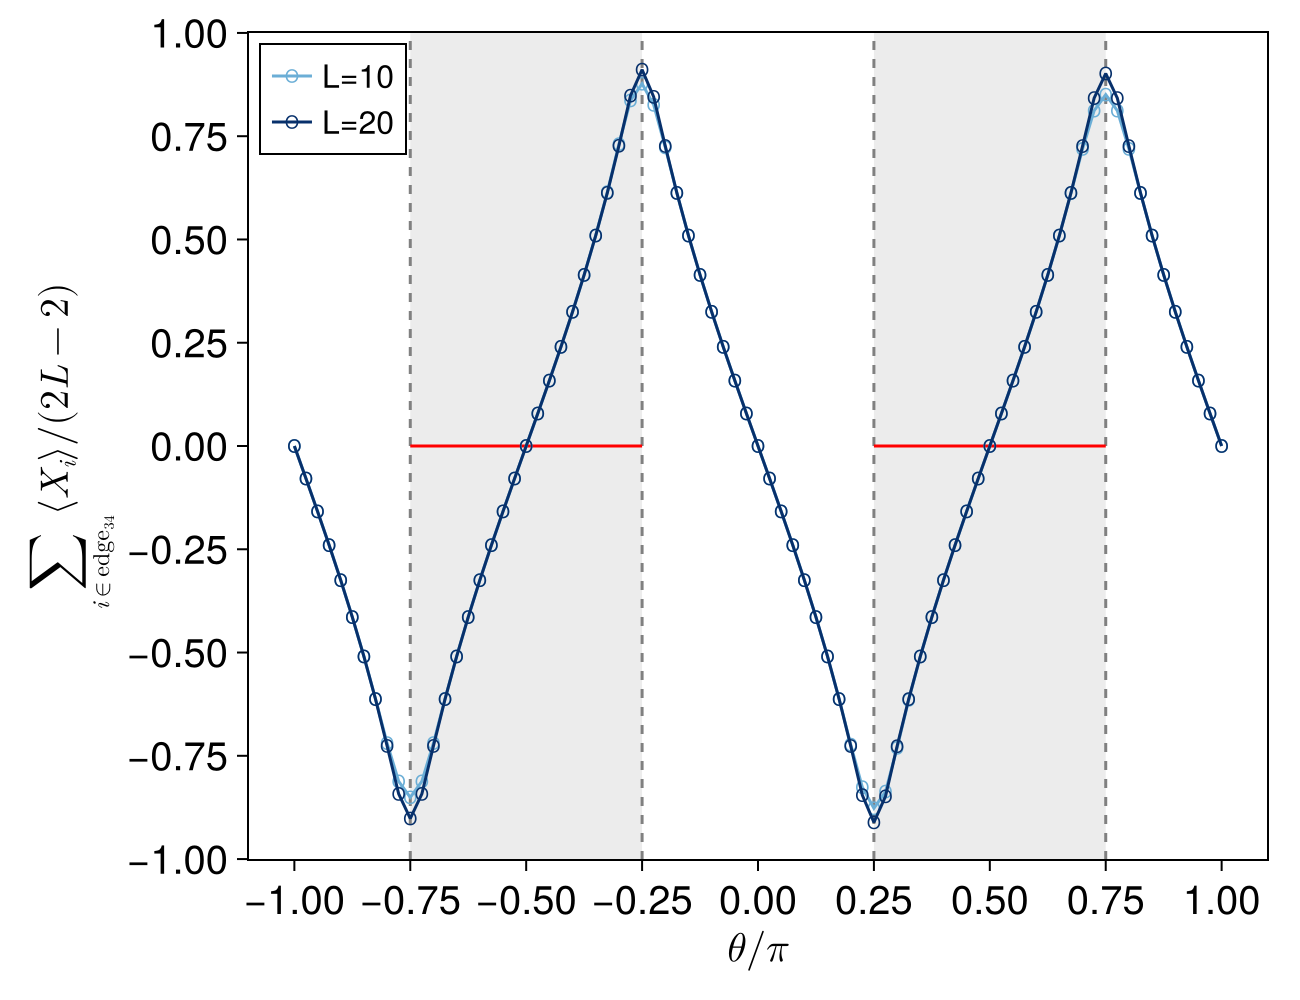

In [30]:
fig = Figure(size=(650,500), fontsize=20)
ax = Axis(fig[1,1], xlabel=L"\theta/\pi", ylabel=L"\sum_{i\in\mathrm{edge_{34}}}⟨X_i⟩/(2L-2)",
        yticks=-1.0:0.25:1.0, xticks=-1.0:0.25:1.0, xgridvisible=false, ygridvisible=false)

# 你要涂黑的区间
bands = [(-3/4, -1/4), (1/4, 3/4)]
# 画灰色（或黑色）填充带
for (x1, x2) in bands
    vspan!(ax, x1, x2; color = (:gray, 0.15))  # 0.15 是透明度，可改大更黑
    vlines!(ax, [x1, x2]; color = :gray, linestyle = :dash, linewidth = 1.5)
end
lines!([-0.75,-0.25],[0.0,0.0], color=:red)
lines!([0.75,0.25],[0.0,0.0], color=:red)
mycl = cgrad(:Blues, length(Ls)+1, categorical = true)[2:end]
for j in eachindex(Ls)
    # scatterlines!(ThetaXs[j]./pi, XL1_s[j], color=mycl[j], marker='O', label="L=$(Ls[j])")
    scatterlines!(ThetaXs[j]./pi, ZZ_s[j], color=mycl[j], marker='O', label="L=$(Ls[j])")
end

axislegend(ax, position=:lt, framevisible=true, labelsize=16)

fig

# Quantum Fisher information

In [3]:
include("mps_funcs.jl")

entanglement_entropy_svd

In [49]:
function calculate_qfi(psi, psi_old, dtheta; cutoff=1E-8, chi=1024)
    dpsi = -(psi, psi_old; cutoff=cutoff, maxdim=chi)
    A = inner(dpsi, dpsi) / (dtheta^2)
    B = abs(inner(dpsi, psi_old))^2 / (dtheta^2)
    return 4*real(A - B)
end

function calculate_qfi_from_total_z(psi, sites; cutoff=1E-8, chi=1024)
  nbits = length(sites)
  zz_ops = OpSum()
  for i0 in 1:nbits
    for i1 in 1:nbits
      if i0==i1
        zz_ops += ("Z",i0,"Z",i0)
      else
        zz_ops += ("Z",i0,"Z",i1)
      end
    end
  end
  zz_ops = MPO(zz_ops, sites)
  szszpsi = apply(zz_ops, psi; cutoff=cutoff, maxdim=chi)
  szsz_val = inner(psi, szszpsi)

  # z_ops = OpSum()
  # for i0 in 1:nbits
  #   z_ops += ("Z", i0)
  # end
  # z_ops = MPO(z_ops, sites)
  # szpsi = apply(z_ops, psi; cutoff=cutoff, maxdim=chi)
  # sz_val = inner(psi, szpsi)
  # print(sz_val)
  szsz_val #- sz_val^2
end

calculate_qfi_from_total_z (generic function with 1 method)

In [22]:
L = 6
chi = 1024
cutoff = 1E-8
N = L^2

36

In [23]:
ket_es = mps_equal_superposition(N)
sites = siteinds(ket_es);

In [44]:
thetas = collect(0:1:160)/40 .* pi/4
println(thetas/pi)

[0.0, 0.00625, 0.0125, 0.01875, 0.025, 0.03125, 0.0375, 0.04375, 0.05, 0.05625, 0.0625, 0.06875, 0.075, 0.08125, 0.0875, 0.09375, 0.1, 0.10625, 0.1125, 0.11875, 0.125, 0.13125, 0.1375, 0.14375, 0.15, 0.15625, 0.1625, 0.16875, 0.175, 0.18125, 0.1875, 0.19375, 0.2, 0.20625, 0.2125, 0.21875, 0.225, 0.23125, 0.2375, 0.24375, 0.25, 0.25625, 0.2625, 0.26875, 0.275, 0.28125, 0.2875, 0.29375, 0.3, 0.30625, 0.3125, 0.31875, 0.325, 0.33125, 0.3375, 0.34374999999999994, 0.35, 0.35625, 0.3625, 0.36875, 0.375, 0.38125, 0.3875, 0.39375, 0.4, 0.40625000000000006, 0.4125, 0.41875, 0.425, 0.43125, 0.4375, 0.44375, 0.45, 0.45625, 0.4625, 0.46874999999999994, 0.475, 0.48125, 0.4875, 0.49375, 0.5, 0.50625, 0.5125, 0.51875, 0.525, 0.53125, 0.5375, 0.54375, 0.55, 0.55625, 0.5625, 0.56875, 0.575, 0.58125, 0.5875, 0.59375, 0.6, 0.60625, 0.6125, 0.61875, 0.625, 0.63125, 0.6375, 0.6437500000000002, 0.65, 0.65625, 0.6625, 0.66875, 0.675, 0.68125, 0.6874999999999999, 0.69375, 0.7, 0.70625, 0.7125, 0.71875, 0.725,

In [50]:
checklinkdim = false
qfi_theta = []
qfi_zz_theta = []
dtheta = thetas[2]-thetas[1]
psi_old = deepcopy(ket_es)
for (i,theta) in enumerate(thetas)
  # println("$(theta/pi)")
  gates = make_sqr_whip_gates_obc(L, theta)
  zytensors = make_tensormap_of_ZY(gates, sites)
  psi = deepcopy(ket_es)
  make_contraction!(gates, zytensors, psi, chi, cutoff, checklinkdim)
  normalize!(psi)
  
  if (L <= 4) & (abs(theta-pi/4)<1e-16)
    s_conf = check_ground_state_configuration(psi)
    println(s_conf)
  end

  # calculate the fisher information
  # if i>1
  #   qfi = calculate_qfi(psi,psi_old,dtheta; cutoff=cutoff, chi=chi)
  #   push!(qfi_theta, qfi)
  # end
  qfi_zz = calculate_qfi_from_total_z(psi, sites; cutoff=cutoff, chi=chi)
  push!(qfi_zz_theta, qfi_zz)

  psi_old = deepcopy(psi)
end

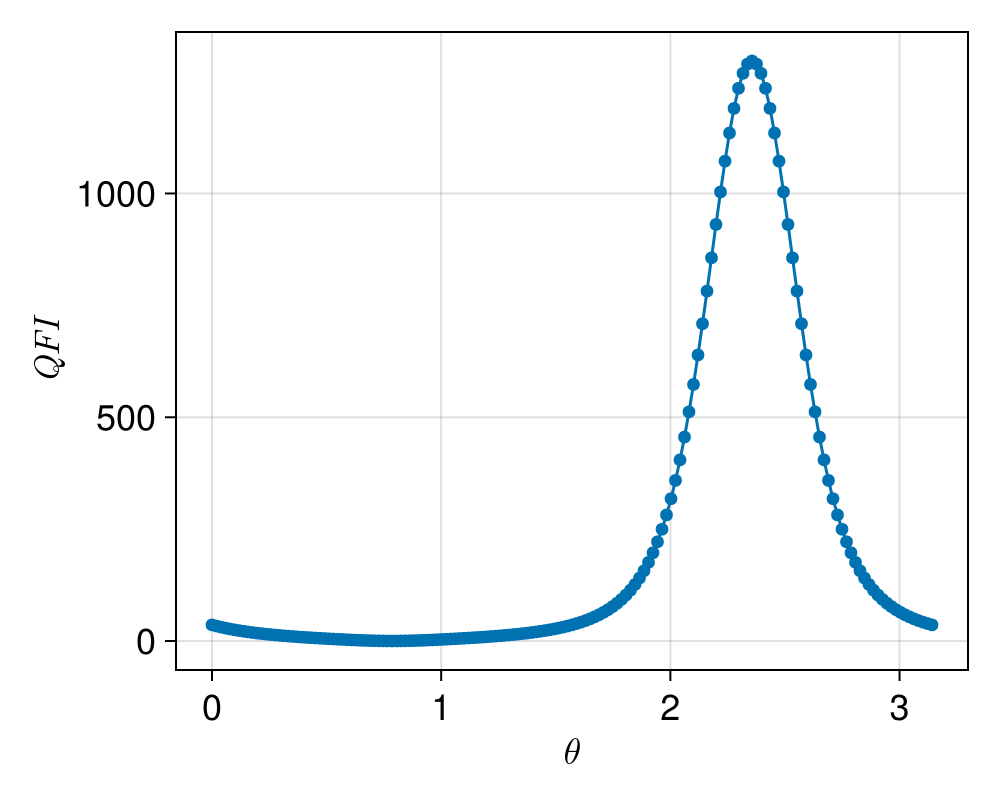

In [51]:
f = Figure(size=(500,400),fontsize=18)
ax = Axis(f[1,1], xlabel=L"\theta", ylabel=L"QFI")

# scatterlines!(thetas[2:end], qfi_theta)
scatterlines!(thetas, qfi_zz_theta)

current_figure()

In [11]:
file_str = "2D_sqr_Whip_QFI_L$(L)_Chi$(chi)"

jldsave("./QFI/$file_str"*".jld2"; 
    saved_qfi=qfi_theta, 
    saved_thetas=thetas
)

In [34]:
Ls = [2,4,6,8,10]
chi = 1024

qfi_l = []
th_l = []
for l in Ls
    file_str = "2D_sqr_Whip_QFI_L$(l)_Chi$(chi)"
    loaded_dict = load("./QFI/$(file_str).jld2")
    push!(qfi_l, loaded_dict["saved_qfi"])
    push!(th_l, loaded_dict["saved_thetas"])
end
qfi_l = stack(qfi_l);
th_l = stack(th_l);

0.0625
0.125
0.1875
0.25
0.3125
0.375
0.4375
0.5


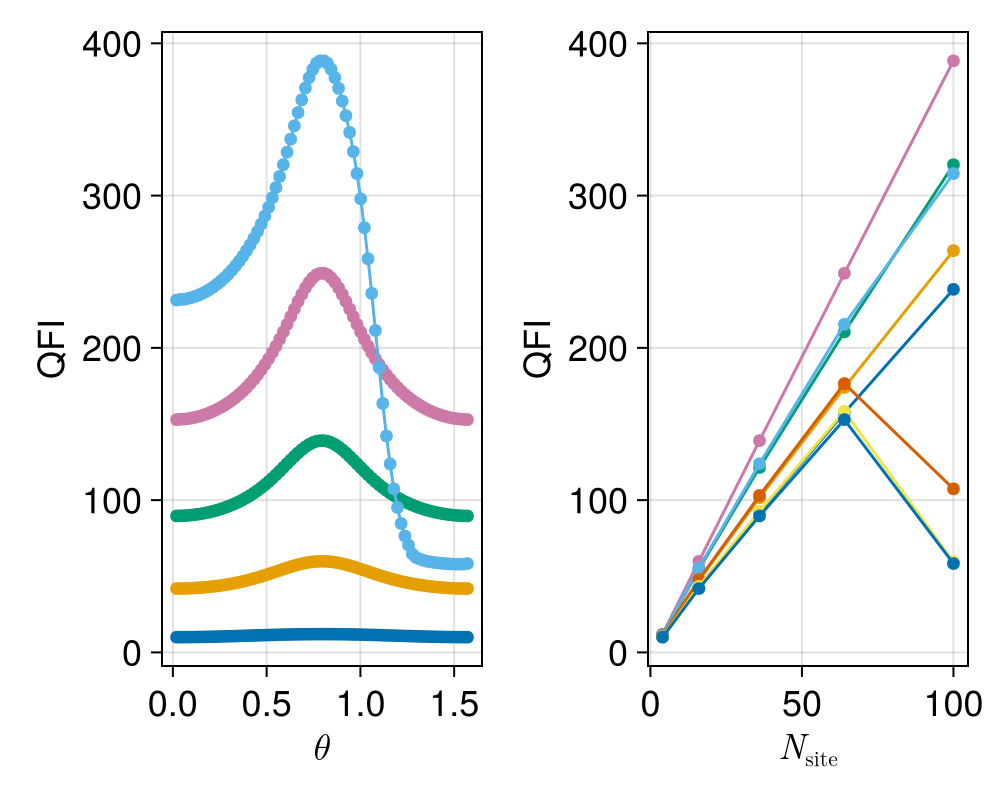

In [36]:
f = Figure(size=(500,400),fontsize=18)
ax = Axis(f[1,1], xlabel=L"\theta", ylabel="QFI")

for i in eachindex(Ls)
    scatterlines!(th_l[2:end,i], qfi_l[:,i])
end

ax2 = Axis(f[1,2], xlabel=L"N_\mathrm{site}", ylabel="QFI")
for j in eachindex(th_l[2:end,1])
    if j%10!=0
        continue
    end
    println(th_l[j+1,1]/pi)
    scatterlines!(Ls.^2, qfi_l[j,:])
end
save("qfi_test.png",f)
current_figure()

# Heisenberg picture

In [3]:
include("peps_funcs.jl")

get_maxlinkdim (generic function with 1 method)

In [4]:
function heisen_local_contraction!(mpo::Vector{ITensor}, mpo2q::MPO, sites::Vector{Index{Int64}})
  u, q = mpo2q[1], mpo2q[2]
  s_i = filter(ind -> (plev(ind)==0 && hastags(ind, "Site")), inds(u))[1]
  qi = findfirst(==(s_i), sites)
  s_j = filter(ind -> (plev(ind)==0 && hastags(ind, "Site")), inds(q))[1]
  qj = findfirst(==(s_j), sites)

  newT2 = locT2 * (mpo[i]*mpo[j]) # contract
  noprime!(newT2)
  indsij = uniqueinds(psi[i],psi[j])
  U,Q = factorize(newT2, indsij, ortho="none", which_decomp="svd", cutoff=cutoff, maxdim=chi)
  psi[i] = U
  psi[j] = Q
end

heisen_local_contraction! (generic function with 1 method)

In [5]:
L = 20
ket_es = twodim_sqr_peps(L, "+"^(L*L));
sites = get_siteinds(ket_es);

In [38]:
cutoff = 1E-8
chi = 4
theta = pi/8

0.39269908169872414

In [39]:
gates = make_sqr_whip_gates_obc(L, theta)
zytensors = make_mpomap_of_ZY(gates, sites);
r_zytensors = reverse(zytensors);

In [27]:
zz_ops = ITensor[]
for i in 1:L^2
    if i<L^2-1
        push!(zz_ops, delta(prime(sites[i]),sites[i]))
    else
        push!(zz_ops, op("Z", sites[i]))
    end
end

In [1]:
for (i,(qi,qj)) in enumerate(reverse(gates.indices))
    zy = r_zytensors[i]
end

UndefVarError: UndefVarError: `gates` not defined

In [ ]:
  println("$(theta/pi)")
  psi = deepcopy(ket_es)
  make_contraction_peps!(gates, zytensors, psi, chi, cutoff)
  # contract to obtain the normalization factor
  val3 = contract_twopeps_naive(psi, psi, chi, cutoff, plev=0)
  # observable
  tmp = []
  for loc in zzs_loc
    i0,i1 = loc
    szpsi = deepcopy(psi)
    szpsi[i0] *= op("Sz", sites[i0])
    noprime!(szpsi[i0], tags="Site")
    szpsi[i1] *= op("Sz", sites[i1])
    noprime!(szpsi[i1], tags="Site")
    szsz_val = contract_twopeps_naive(szpsi, psi, chi, cutoff, plev=0)
    push!(tmp, real(szsz_val/val3))
  end
  push!(zz_theta, tmp)
end
zz_theta = stack(zz_theta);

In [40]:
zytensors[1]

MPO
[1] ((dim=2|id=986|"Qubit,Site,n=1"), (dim=2|id=986|"Qubit,Site,n=1")', (dim=2|id=775|"Link,l=1"))
[2] ((dim=2|id=1|"Qubit,Site,n=21"), (dim=2|id=1|"Qubit,Site,n=21")', (dim=2|id=775|"Link,l=1"))


In [16]:
T0 = op("Z", sites, 1)

ITensor ord=2 (dim=2|id=672|"Qubit,Site,n=1")' (dim=2|id=672|"Qubit,Site,n=1")
NDTensors.Dense{Float64, Vector{Float64}}

In [17]:
T0[sites[1]'=>1,sites[1]=>1] = 1.0
T0[sites[1]'=>2,sites[1]=>2] = 0.0

0.0

In [18]:
array(T0)

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  0.0

# JLD2 to JSON

In [171]:
using JLD2
using JSON

In [174]:
L = 100
CHIs = Array(4:2:30)
# println(CHIs)
chi = 32 # CHIs[end]
cutoff = 1E-16

# 2. Load the data from the JLD2 file
# ------------------------------------
dirstr = "./data/scaling"
# filestr = "2D_sqr_PEPS_Whip_MPO_L$(L)_Chi$(chi)_ZZ_scaling"
filestr = "2D_sqr_PEPS_Whip_MPO_L$(L)_Chi$(chi)_ZZ_$(chi)_$(cutoff)_finer"
jldata = JLD2.load("$dirstr/$filestr"*".jld2")
display(jldata)
# 3. Convert the data to JSON format and save to a .json file
# ------------------------------------------------------------
# The loaded_data is a dictionary, which is generally compatible with JSON types.
open("$dirstr/$filestr.json", "w") do io
    JSON.print(io, jldata, 4)
end

println("Data successfully loaded from mydata.jld2 and saved to output.json")

Dict{String, Any} with 4 entries:
  "saved_zz"       => [-8.54373e-5, -8.68478e-5, -8.83231e-5, -8.98918e-5, -9.1…
  "total_time_sec" => 851.355
  "saved_linkdim"  => [[16, 32, 32, 32, 32, 32, 32, 32, 32, 32  …  32, 32, 32, …
  "saved_thetas"   => [0.706858, 0.714712, 0.722566, 0.73042, 0.738274, 0.74612…

Data successfully loaded from mydata.jld2 and saved to output.json
